# 🤖 Social Media Fake Account Detection

## Project Overview
The goal of this project is to build a Machine Learning model
that detects fake accounts on social media platforms.

**Dataset:** 5,000 accounts (2,500 fake + 2,500 real)
**Framework:** OSEMN
**Models:** Logistic Regression, Random Forest
**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn
**Author:** Michał Mańkowski

## OSEMN Framework

This project follows the OSEMN data science framework:

- **O**btain — Load dataset (fake and real social media accounts)
- **S**crub — Clean data, handle missing values, select features
- **E**xplore — Visualize and understand the data
- **M**odel — Train and evaluate ML models
- **i**Nterpret — Draw conclusions and build Streamlit app

## Step 1: Obtain — Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
fake = pd.read_csv('Data/fake_users.csv')
real = pd.read_csv('Data/real_users.csv')

print(f"Fake accounts: {fake.shape}")
print(f"Real accounts: {real.shape}")
print(f"\nColumns: {fake.columns.tolist()}")

Fake accounts: (2500, 34)
Real accounts: (2500, 34)

Columns: ['id', 'name', 'screen_name', 'statuses_count', 'followers_count', 'friends_count', 'favourites_count', 'listed_count', 'created_at', 'url', 'lang', 'time_zone', 'location', 'default_profile', 'default_profile_image', 'geo_enabled', 'profile_image_url', 'profile_banner_url', 'profile_use_background_image', 'profile_background_image_url_https', 'profile_text_color', 'profile_image_url_https', 'profile_sidebar_border_color', 'profile_background_tile', 'profile_sidebar_fill_color', 'profile_background_image_url', 'profile_background_color', 'profile_link_color', 'utc_offset', 'protected', 'verified', 'description', 'updated', 'dataset']


## Step 2: Scrub — Clean & Prepare Data

In [4]:
# Add labels
fake['is_fake'] = 1
real['is_fake'] = 0

# Combine into one dataset
df = pd.concat([fake, real], ignore_index=True)

print(f"Combined dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['is_fake'].value_counts())
print(f"\nClass balance: {df['is_fake'].value_counts(normalize=True).round(2).to_dict()}")

Combined dataset shape: (5000, 35)

Label distribution:
is_fake
1    2500
0    2500
Name: count, dtype: int64

Class balance: {1: 0.5, 0: 0.5}


### Feature Selection & Handling Missing Values

In [5]:
# Select relevant features
features = [
    'statuses_count',
    'followers_count',
    'friends_count',
    'favourites_count',
    'listed_count',
    'default_profile',
    'default_profile_image',
    'geo_enabled',
    'profile_use_background_image',
    'profile_background_tile',
    'utc_offset',
    'protected',
    'verified'
]

# Keep only selected features + label
df_model = df[features + ['is_fake']].copy()

# Handle missing values
print("Missing values before fillna:")
print(df_model.isnull().sum())

df_model = df_model.fillna(0)

print(f"\nMissing values after fillna: {df_model.isnull().sum().sum()}")
print(f"\nDataset ready: {df_model.shape}")

Missing values before fillna:
statuses_count                  0
followers_count                 0
friends_count                   0
favourites_count                0
listed_count                    0
default_profile                 0
default_profile_image           0
geo_enabled                     0
profile_use_background_image    0
profile_background_tile         0
utc_offset                      0
protected                       0
verified                        0
is_fake                         0
dtype: int64

Missing values after fillna: 0

Dataset ready: (5000, 14)


## Step 3: Explore — Exploratory Data Analysis

### 3.1 Basic Statistics

In [6]:
# Basic statistics
print("Dataset statistics:")
df_model.describe().round(2)

Dataset statistics:


,statuses_count,followers_count,friends_count,favourites_count,listed_count,default_profile,default_profile_image,geo_enabled,profile_use_background_image,profile_background_tile,utc_offset,protected,verified,is_fake
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.0,5000.0,5000.0
mean,1313.80,321.92,315.36,183.11,2.12,0.49,0.00,0.18,0.79,0.13,1137.57,0.0,0.0,0.5
std,6463.09,11351.15,668.12,1765.44,23.24,0.96,0.06,0.62,1.13,0.52,4082.95,0.0,0.0,0.5
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.5
75%,117.34,39.72,394.47,0.00,0.00,0.54,0.00,0.00,1.44,0.00,0.00,0.0,0.0,1.0
max,139674.31,796096.38,16878.47,60892.17,915.63,7.09,2.24,6.45,6.24,5.87,93605.26,0.0,0.0,1.0


### 3.2 Class Distribution

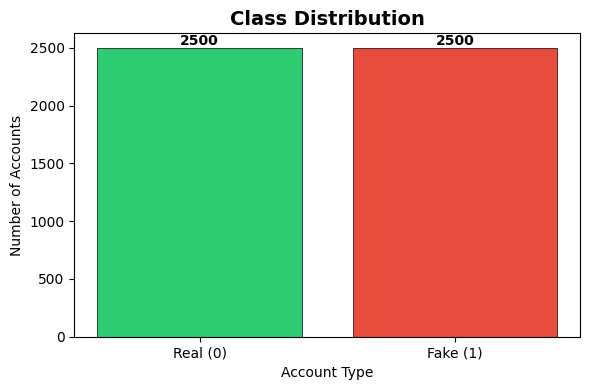

In [7]:
# Class distribution plot
fig, ax = plt.subplots(figsize=(6, 4))

colors = ['#2ecc71', '#e74c3c']
labels = ['Real (0)', 'Fake (1)']
values = df_model['is_fake'].value_counts().sort_index()

ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Accounts')
ax.set_xlabel('Account Type')

for i, v in enumerate(values):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.3 Feature Comparison: Fake vs Real

C:\Users\micha\AppData\Local\Temp\ipykernel_32692\2504684273.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([real_data, fake_data], labels=['Real', 'Fake'],
C:\Users\micha\AppData\Local\Temp\ipykernel_32692\2504684273.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([real_data, fake_data], labels=['Real', 'Fake'],
C:\Users\micha\AppData\Local\Temp\ipykernel_32692\2504684273.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([real_data, fake_data], labels=['Real', 'Fake'],
C:\Users\micha\AppData\Local\Temp\ipykernel_32692\2504684273.py:16: MatplotlibDeprecationWarning: The '

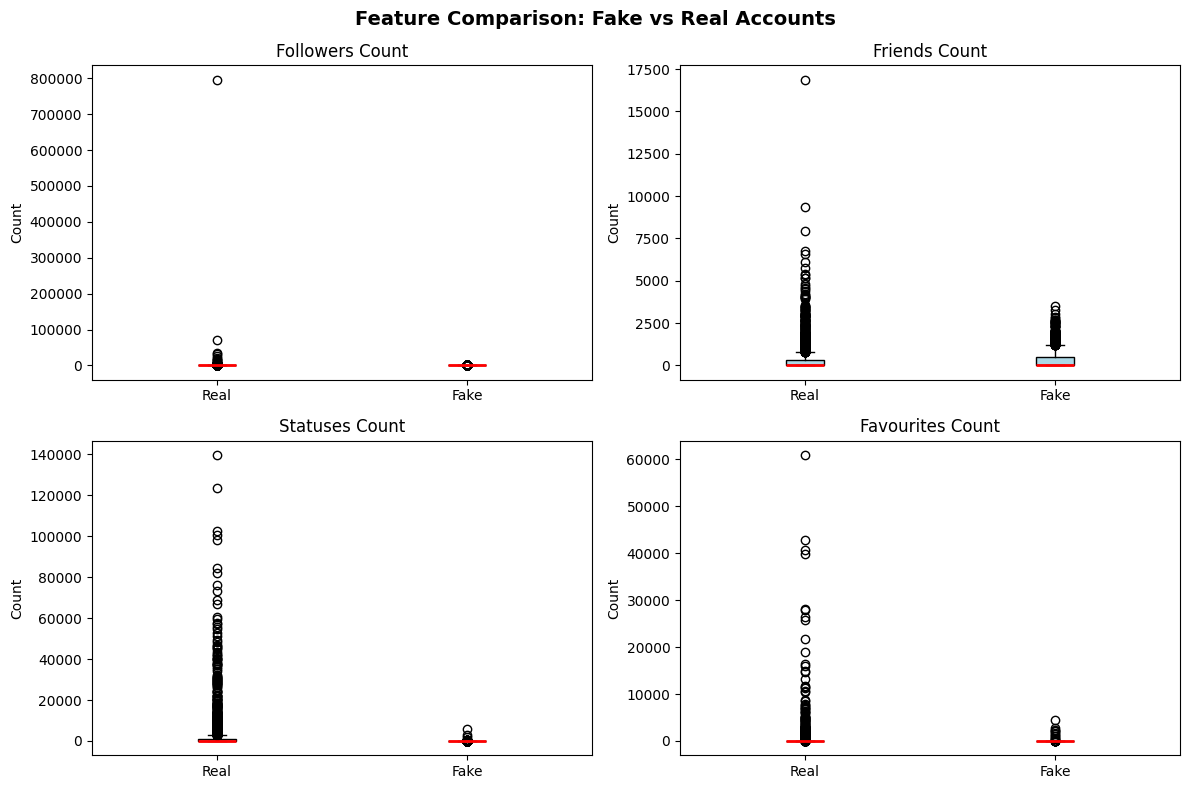

In [8]:
# Compare key features between fake and real accounts
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Comparison: Fake vs Real Accounts',
             fontsize=14, fontweight='bold')

features_to_plot = ['followers_count', 'friends_count',
                    'statuses_count', 'favourites_count']
colors = ['#2ecc71', '#e74c3c']

for i, feature in enumerate(features_to_plot):
    ax = axes[i//2, i%2]

    real_data = df_model[df_model['is_fake']==0][feature]
    fake_data = df_model[df_model['is_fake']==1][feature]

    ax.boxplot([real_data, fake_data], labels=['Real', 'Fake'],
               patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2))

    ax.set_title(feature.replace('_', ' ').title())
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

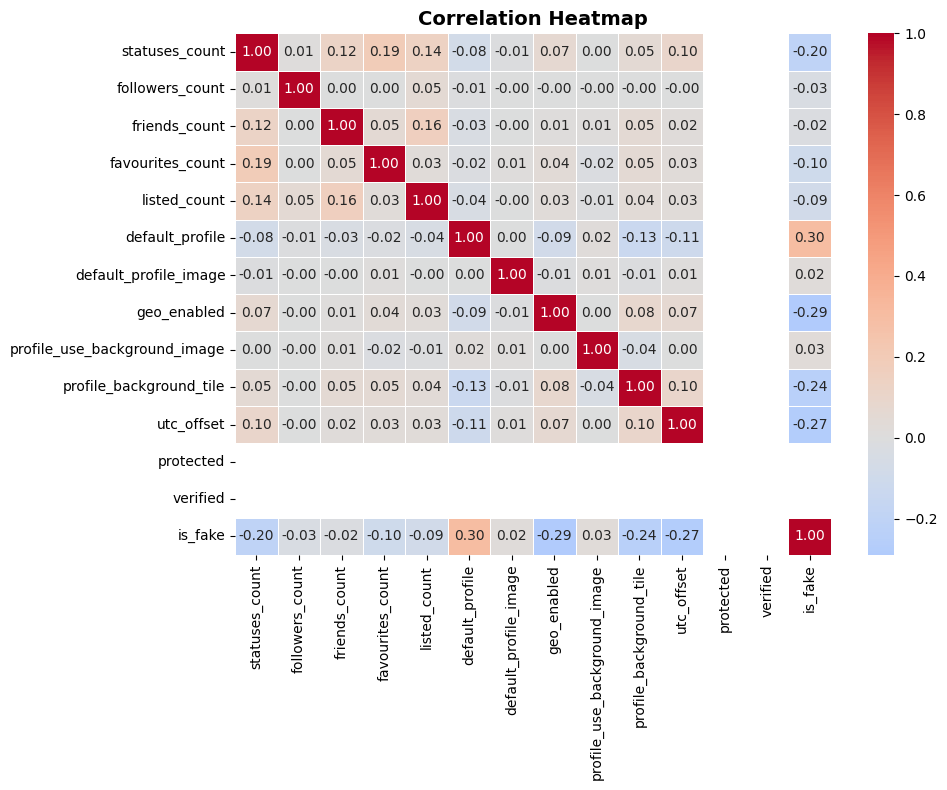

In [9]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = df_model.corr().round(2)

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            ax=ax,
            linewidths=0.5)

ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Model — Machine Learning

### 4.1 Train/Test Split

In [11]:
from sklearn.model_selection import train_test_split

X = df_model[features]
y = df_model['is_fake']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")
print(f"\nTrain label distribution:\n{y_train.value_counts()}")
print(f"\nTest label distribution:\n{y_test.value_counts()}")

Train size: 4000 samples
Test size:  1000 samples

Train label distribution:
is_fake
1    2000
0    2000
Name: count, dtype: int64

Test label distribution:
is_fake
0    500
1    500
Name: count, dtype: int64


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scaler dla Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
print(" Logistic Regression trained!")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print(" Random Forest trained!")

 Logistic Regression trained!
 Random Forest trained!


### 4.3 Model Evaluation

In [14]:
from sklearn.metrics import classification_report, roc_auc_score

# Predictions
lr_pred = lr.predict(X_test_scaled)
rf_pred = rf.predict(X_test)

# AUC-ROC
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("── Logistic Regression ──")
print(classification_report(y_test, lr_pred, target_names=['Real', 'Fake']))
print(f"AUC-ROC: {lr_auc:.4f}")

print("\n── Random Forest ──")
print(classification_report(y_test, rf_pred, target_names=['Real', 'Fake']))
print(f"AUC-ROC: {rf_auc:.4f}")

── Logistic Regression ──
              precision    recall  f1-score   support

        Real       0.99      0.68      0.80       500
        Fake       0.75      0.99      0.86       500

    accuracy                           0.83      1000
   macro avg       0.87      0.83      0.83      1000
weighted avg       0.87      0.83      0.83      1000

AUC-ROC: 0.8963

── Random Forest ──
              precision    recall  f1-score   support

        Real       0.94      0.89      0.91       500
        Fake       0.89      0.94      0.92       500

    accuracy                           0.91      1000
   macro avg       0.92      0.91      0.91      1000
weighted avg       0.92      0.91      0.91      1000

AUC-ROC: 0.9555


### 4.4 Results Visualization

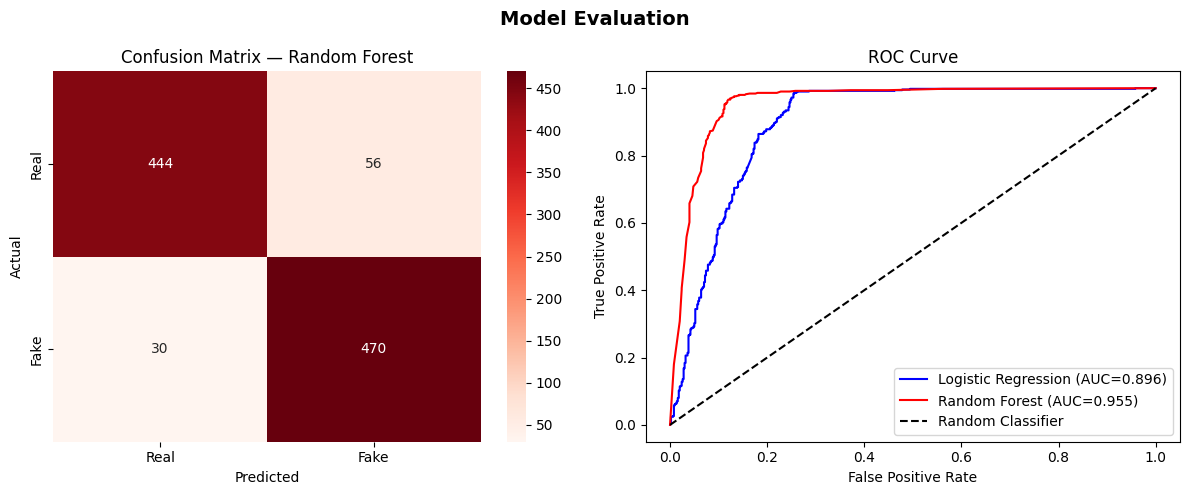

In [15]:
from sklearn.metrics import confusion_matrix, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Evaluation', fontsize=14, fontweight='bold')

# Plot 1: Confusion Matrix - Random Forest
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
axes[0].set_title('Confusion Matrix — Random Forest')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Plot 2: ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_scaled)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])

axes[1].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_auc:.3f})', color='blue')
axes[1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_auc:.3f})', color='red')
axes[1].plot([0,1],[0,1],'k--', label='Random Classifier')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.5 Feature Importance

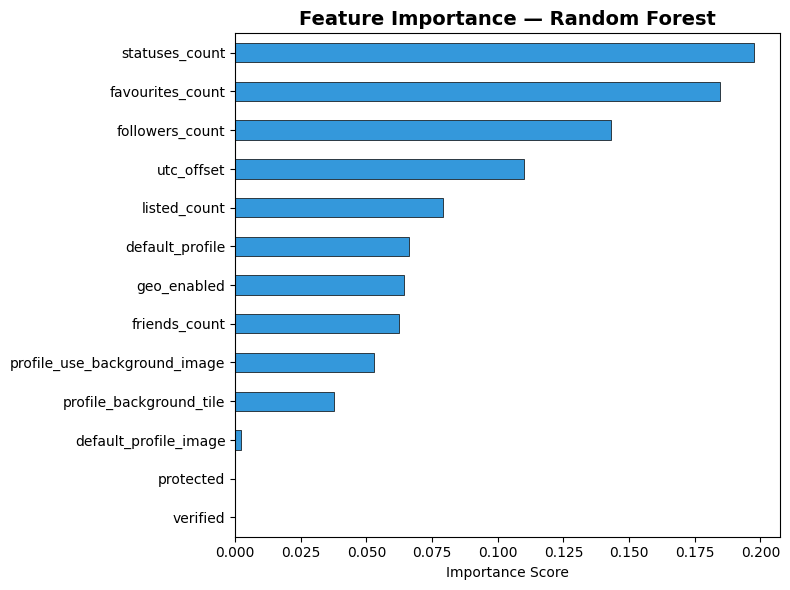

In [16]:
# Feature Importance
fig, ax = plt.subplots(figsize=(8, 6))

feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values()

feat_imp.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black', linewidth=0.5)

ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()